In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dp = r"C:\Users\snong\Desktop\20260514_YAK_Data\0bd7a013-c6c6-4487-a200-03a7a0542130.csv"
df = pd.read_csv(dp)

In [3]:
df

,record_time,sub_index,rri,area_up,area_down,motion
0,2025-03-12 11:02:44,0,680,912,912,743
1,2025-03-12 11:02:45,0,670,910,910,473
2,2025-03-12 11:02:45,1,720,908,908,89
3,2025-03-12 11:02:46,0,750,906,906,131
4,2025-03-12 11:02:47,0,440,903,903,37
...,...,...,...,...,...,...
102979,2025-03-13 10:09:46,1,630,537,954,35
102980,2025-03-13 10:09:47,0,710,537,954,1
102981,2025-03-13 10:09:47,1,590,537,954,120
102982,2025-03-13 10:09:48,0,430,537,954,243


<Axes: >

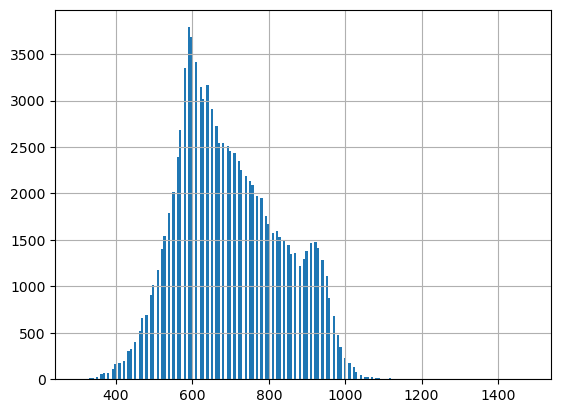

In [4]:
x = df.rri
x.hist(bins=200)

<Axes: >

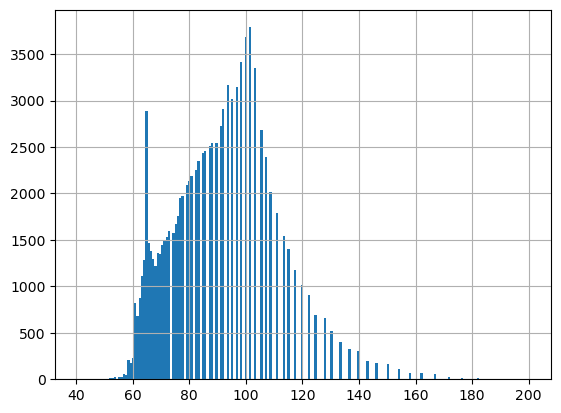

In [5]:
h = 6e4 / x
h.hist(bins=200)

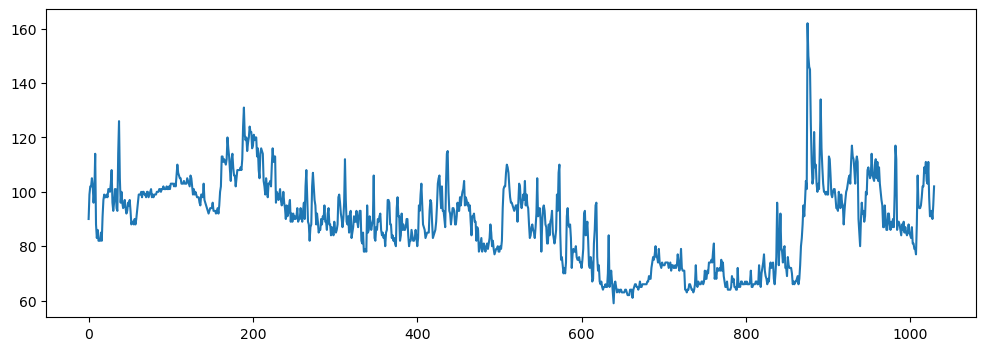

In [6]:
hg = h.groupby(np.arange(len(df)) // 100).mean().values.astype(int)
plt.figure(figsize=(12, 4))
plt.plot(hg)
plt.show()

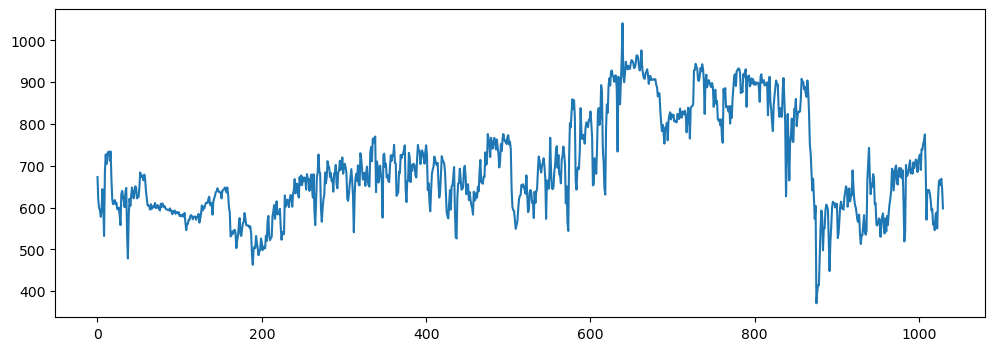

In [7]:
xg = x.groupby(np.arange(len(df)) // 100).mean().values.astype(int)
plt.figure(figsize=(12, 4))
plt.plot(xg)
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# 假设你的数据是 x （这里仅做防报错处理，实际运行时删除此行）
# x = np.random.randn(105000) 

# 1. 核心优化：图形只初始化一次，不要放进 update 函数里
fig, ax = plt.subplots(figsize=(18, 4))
line, = ax.plot(h, '-o', linewidth=0.8, markersize=3)
plt.close(fig) # 隐藏默认的静态输出，由下面的 display 接管

# 2. 定义交互逻辑
def update_view(start, window_size):
    # 计算当前窗口的结束位置
    end = min(start + window_size, len(x))
    
    # 只更新 X 轴的显示范围，不重新画线
    ax.set_xlim(start, end)
    
    # 根据当前窗口内的数据动态调整 Y 轴，防止波形超出边界或太扁平
    current_data = x[start:end]
    if len(current_data) > 0:
        y_min, y_max = current_data.min(), current_data.max()
        margin = (y_max - y_min) * 0.1
        if margin == 0: margin = 1
        # ax.set_ylim(y_min - margin, y_max + margin)
        ax.set_ylim(0, 200)
    
    # 触发画布刷新
    display(fig)

# 3. 配置滑条参数
# 关键设置：continuous_update=False，只有松开鼠标时才刷新，彻底告别失灵
start_slider = widgets.IntSlider(
    min=0, max=len(x)-100, step=1000, value=0, 
    description='起始位置:', layout=widgets.Layout(width='80%'), 
    continuous_update=False
)

window_slider = widgets.IntSlider(
    min=100, max=len(x), step=1000, value=100, 
    description='窗口大小:', layout=widgets.Layout(width='80%'), 
    continuous_update=False
)

# 4. 启动交互
interact(update_view, start=start_slider, window_size=window_slider);

interactive(children=(IntSlider(value=0, continuous_update=False, description='起始位置:', layout=Layout(width='80…